In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

DATA_RAW    = Path('../data/raw/telecom_churn_raw.csv')
DATA_PROCESSED = Path('../data/processed/')
DATA_PROCESSED.mkdir(exist_ok=True)
FIGURES_PATH = Path('../notebooks/figures')

df_raw = pd.read_csv(DATA_RAW)

print(f"Shape brut     : {df_raw.shape}")
print(f"Nulls total    : {df_raw.isnull().sum().sum()}")
print(f"Churn rate     : {df_raw['churn'].mean():.1%}")

Shape brut     : (15120, 18)
Nulls total    : 2838
Churn rate     : 47.6%


In [2]:
# Keep an untouched reference copy
df_original = df_raw.copy()
df = df_raw.copy()

# Initial data quality report — documented starting point
def quality_report(dataframe, label="Dataset"):
    print(f"\n{'═'*55}")
    print(f"  DATA QUALITY REPORT — {label}")
    print(f"{'═'*55}")
    print(f"  Shape              : {dataframe.shape}")
    print(f"  Exact duplicates   : {dataframe.duplicated().sum()}")
    print(f"  Total null values  : {dataframe.isnull().sum().sum()}")

    missing = dataframe.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        print(f"\n  Missing values :")
        for col, n in missing.items():
            print(
                f"    {col:<22} {n:>5} "
                f"({n/len(dataframe)*100:.1f}%)"
            )

    print(f"\n  Numerical outliers :")
    for col in ['monthly_charges', 'age', 'tenure_months']:
        data = dataframe[col].dropna()
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        iqr = q3 - q1
        n_out = ((data < q1 - 1.5 * iqr) |
                 (data > q3 + 1.5 * iqr)).sum()

        print(f"    {col:<22} {n_out:>5} IQR outliers")

quality_report(df, "BEFORE CLEANING")


═══════════════════════════════════════════════════════
  DATA QUALITY REPORT — BEFORE CLEANING
═══════════════════════════════════════════════════════
  Shape              : (15120, 18)
  Exact duplicates   : 0
  Total null values  : 2838

  Missing values :
    age                      578 (3.8%)
    gender                   221 (1.5%)
    tenure_months            442 (2.9%)
    monthly_charges          301 (2.0%)
    total_charges            930 (6.2%)
    payment_method           366 (2.4%)

  Numerical outliers :
    monthly_charges          108 IQR outliers
    age                        8 IQR outliers
    tenure_months             27 IQR outliers


In [4]:
print("── STEP 1: Duplicates ──")
print(f"Shape before : {df.shape}")

# Exact duplicates
n_exact = df.duplicated().sum()
print(f"\nExact duplicates   : {n_exact}")
df = df.drop_duplicates()

# Partial duplicates — same customer, multiple records
# Keep the first occurrence
n_before = len(df)
df = df.drop_duplicates(
    subset=['tenure_months', 'monthly_charges',
            'contract', 'internet_service',
            'payment_method'],
    keep='first'
)
n_partial = n_before - len(df)
print(f"Partial duplicates : {n_partial}")
print(f"\nShape after        : {df.shape}")
print(f"Rows removed       : "
      f"{len(df_original) - len(df)}")

# Validation check
assert df.duplicated(
    subset=['tenure_months', 'monthly_charges',
            'contract', 'internet_service',
            'payment_method']
).sum() == 0, "Remaining duplicates detected"

print("\n✓ No duplicates remaining")

── STEP 1: Duplicates ──
Shape before : (15025, 18)

Exact duplicates   : 0
Partial duplicates : 0

Shape after        : (15025, 18)
Rows removed       : 95

✓ No duplicates remaining


In [5]:
print("── STEP 2: Categorical Standardization ──")

# ── gender ────────────────────────────────────────────
print(f"\ngender before : {df['gender'].nunique()} unique values")
print(df['gender'].value_counts().to_string())

gender_map = {
    # Standard values
    'Male'   : 'Male',
    'Female' : 'Female',

    # Lowercase variations
    'male'   : 'Male',
    'female' : 'Female',

    # Uppercase variations
    'MALE'   : 'Male',
    'FEMALE' : 'Female',

    # Abbreviations
    'M'      : 'Male',
    'F'      : 'Female',

    # Other languages
    'féminin': 'Female',
    'Femme'  : 'Female',
}

# Robust cleaning: strip whitespace first
df['gender'] = df['gender'].astype(str).str.strip()
df['gender'] = df['gender'].map(gender_map)

# Values not found in the mapping become NaN
# (they will be imputed later)

print(f"\ngender after : {df['gender'].nunique()} unique values")
print(df['gender'].value_counts(dropna=False).to_string())

# ── contract ──────────────────────────────────────────
print(f"\ncontract before : {df['contract'].nunique()} unique values")

def standardize_contract(val):
    if pd.isna(val):
        return np.nan

    val = str(val).strip().lower()

    if any(x in val for x in ['month', 'mensuel', 'm-t-m']):
        return 'Month-to-month'
    elif any(x in val for x in ['one', 'un', '1 year', '1year']):
        return 'One year'
    elif any(x in val for x in ['two', 'deux', '2 year', '2year']):
        return 'Two year'

    return np.nan

df['contract'] = df['contract'].apply(standardize_contract)

print(f"contract after : {df['contract'].nunique()} unique values")
print(df['contract'].value_counts(dropna=False).to_string())

# ── payment_method ────────────────────────────────────
print(f"\npayment_method before : {df['payment_method'].nunique()} unique values")

def standardize_payment(val):
    if pd.isna(val):
        return np.nan

    val = str(val).strip().lower().replace('-', ' ').replace('_', ' ')

    if 'electronic' in val or 'e check' in val:
        return 'Electronic check'
    elif 'mailed' in val or 'mail' in val:
        return 'Mailed check'
    elif 'bank' in val or 'transfer' in val:
        return 'Bank transfer'
    elif 'credit' in val or 'card' in val:
        return 'Credit card'

    return np.nan

df['payment_method'] = df['payment_method'].apply(standardize_payment)

print(f"payment_method after : {df['payment_method'].nunique()} unique values")
print(df['payment_method'].value_counts(dropna=False).to_string())

── STEP 2: Categorical Standardization ──

gender before : 11 unique values
gender
Female     7224
Male       7126
FEMALE       61
male         54
F            54
Femme        53
MALE         49
female       49
féminin      48
 Male        44
M            42

gender after : 2 unique values
gender
Female    7489
Male      7315
NaN        221

contract before : 10 unique values
contract after : 3 unique values
contract
Month-to-month    8245
One year          3609
Two year          3171

payment_method before : 10 unique values
payment_method after : 4 unique values
payment_method
Electronic check    4885
Mailed check        3357
Bank transfer       3229
Credit card         3188
NaN                  366


In [6]:
print("── STEP 3: Logical Inconsistencies ──")

# Inconsistency 1: No internet service but online_security = Yes
mask_inc1 = (
    (df['internet_service'] == 'No') &
    (df['online_security'] == 'Yes')
)

print(f"\nNo internet + security=Yes : {mask_inc1.sum()} rows")

df.loc[mask_inc1, 'online_security'] = 'No'
df.loc[
    df['internet_service'] == 'No', 'streaming_tv'
] = 'No'

print("→ Corrected: online_security and streaming_tv set to 'No'")

# Inconsistency 2: total_charges = 0 despite long tenure
mask_inc2 = (
    (df['total_charges'] == 0) &
    (df['tenure_months'] > 24)
)

print(f"\nTotal charges=0 + tenure>24 : {mask_inc2.sum()} rows")

# Correction: recalculate using monthly_charges × tenure
df.loc[mask_inc2, 'total_charges'] = (
    df.loc[mask_inc2, 'monthly_charges'] *
    df.loc[mask_inc2, 'tenure_months']
).round(2)

print("→ Corrected: total_charges recalculated")

# Validation check
remaining_inc1 = (
    (df['internet_service'] == 'No') &
    (df['online_security'] == 'Yes')
).sum()

remaining_inc2 = (
    (df['total_charges'] == 0) &
    (df['tenure_months'] > 24)
).sum()

print(f"\n✓ Remaining inconsistency 1 : {remaining_inc1}")
print(f"✓ Remaining inconsistency 2 : {remaining_inc2}")

── STEP 3: Logical Inconsistencies ──

No internet + security=Yes : 82 rows
→ Corrected: online_security and streaming_tv set to 'No'

Total charges=0 + tenure>24 : 40 rows
→ Corrected: total_charges recalculated

✓ Remaining inconsistency 1 : 0
✓ Remaining inconsistency 2 : 0


In [7]:
print("── STEP 4: Outlier Handling ──")

outlier_log = {}

# ── monthly_charges ───────────────────────────────────
col = 'monthly_charges'
data = df[col].dropna()

# Business rule: realistic maximum telecom plan cost = $200
business_max = 200.0
business_min = 0.0

mask_high = df[col] > business_max
mask_neg  = df[col] < business_min

print(f"\n{col} :")
print(f"  Values > {business_max} : {mask_high.sum()} rows")
print(f"  Values < 0              : {mask_neg.sum()} rows")

# Values multiplied by 10 by mistake → divide by 10
mask_x10 = (df[col] > business_max) & (df[col] < business_max * 10)

df.loc[mask_x10, col] = (
    df.loc[mask_x10, col] / 10
).round(2)

print(f"  Corrected by dividing by 10 : {mask_x10.sum()}")

# Remaining values > 200 or negative
# → replace with median by internet_service group
cap_median = df.groupby('internet_service')[col].median()

for service in df['internet_service'].dropna().unique():
    mask_bad = (
        (df['internet_service'] == service) &
        ((df[col] > business_max) | (df[col] < 0))
    )

    if mask_bad.sum() > 0:
        df.loc[mask_bad, col] = cap_median[service]
        print(
            f"  Replaced with group median "
            f"({service}) : {mask_bad.sum()} rows"
        )

outlier_log[col] = mask_high.sum() + mask_neg.sum()

# ── age ───────────────────────────────────────────────
col = 'age'
data = df[col].dropna()

# Business rule: customer age must be between 18 and 100
mask_age_bad = (df[col] < 18) | (df[col] > 100)
n_bad_age = mask_age_bad.sum()

print(f"\n{col} :")
print(f"  Values outside [18–100] : {n_bad_age} rows")

# Convert invalid values to NaN
# (they will be imputed in the next step)
df.loc[mask_age_bad, col] = np.nan

print("  → Set to NaN (will be imputed)")
outlier_log[col] = n_bad_age

# ── tenure_months ─────────────────────────────────────
col = 'tenure_months'

# Business rule: maximum contract duration is 72 months
mask_tenure_bad = df[col] > 72
n_bad_tenure = mask_tenure_bad.sum()

print(f"\n{col} :")
print(f"  Values > 72 : {n_bad_tenure} rows")

df.loc[mask_tenure_bad, col] = np.nan

print("  → Set to NaN (will be imputed)")
outlier_log[col] = n_bad_tenure

print(f"\nSummary of handled outliers : {outlier_log}")

── STEP 4: Outlier Handling ──

monthly_charges :
  Values > 200.0 : 74 rows
  Values < 0              : 34 rows
  Corrected by dividing by 10 : 74
  Replaced with group median (No) : 8 rows
  Replaced with group median (DSL) : 15 rows
  Replaced with group median (Fiber optic) : 11 rows

age :
  Values outside [18–100] : 29 rows
  → Set to NaN (will be imputed)

tenure_months :
  Values > 72 : 30 rows
  → Set to NaN (will be imputed)

Summary of handled outliers : {'monthly_charges': np.int64(108), 'age': np.int64(29), 'tenure_months': np.int64(30)}


In [8]:
print("── STEP 5: Imputation ──")
print(f"Missing values before imputation : {df.isnull().sum().sum()}")
print()

# ── Strategy per column ─────────────────────────────
# Rule: symmetric distribution → mean
#       skewed distribution → median
#       categorical → mode

imputation_log = {}

# tenure_months : median by contract
# (tenure depends on contract type — business logic)
col = 'tenure_months'
n_missing = df[col].isnull().sum()

tenure_medians = df.groupby('contract')[col].median()

for contract_type in df['contract'].dropna().unique():
    mask = (
        df[col].isnull() &
        (df['contract'] == contract_type)
    )
    df.loc[mask, col] = tenure_medians[contract_type]

# Remaining cases without known contract
df[col] = df[col].fillna(df[col].median())
df[col] = df[col].round(0)

imputation_log[col] = (
    f"median by contract "
    f"({n_missing} rows)"
)

# monthly_charges : median by internet_service
col = 'monthly_charges'
n_missing = df[col].isnull().sum()

mc_medians = df.groupby('internet_service')[col].median()

for service in df['internet_service'].dropna().unique():
    mask = (
        df[col].isnull() &
        (df['internet_service'] == service)
    )
    df.loc[mask, col] = mc_medians.get(service, df[col].median())

df[col] = df[col].fillna(df[col].median())

imputation_log[col] = (
    f"median by internet_service "
    f"({n_missing} rows)"
)

# total_charges : business recalculation
col = 'total_charges'
n_missing = df[col].isnull().sum()

mask_null_tc = df[col].isnull()

df.loc[mask_null_tc, col] = (
    df.loc[mask_null_tc, 'monthly_charges'] *
    df.loc[mask_null_tc, 'tenure_months']
).round(2)

imputation_log[col] = (
    f"tenure × monthly_charges "
    f"({n_missing} rows)"
)

# age : global median
# (no meaningful grouping available)
col = 'age'
n_missing = df[col].isnull().sum()

age_median = df[col].median()
df[col] = df[col].fillna(age_median)
df[col] = df[col].round(0).astype(int)

imputation_log[col] = (
    f"global median "
    f"({age_median:.0f} years, "
    f"{n_missing} rows)"
)

# gender : mode
col = 'gender'
n_missing = df[col].isnull().sum()

gender_mode = df[col].mode()[0]
df[col] = df[col].fillna(gender_mode)

imputation_log[col] = (
    f"mode ({gender_mode}, "
    f"{n_missing} rows)"
)

# payment_method : mode
col = 'payment_method'
n_missing = df[col].isnull().sum()

pay_mode = df[col].mode()[0]
df[col] = df[col].fillna(pay_mode)

imputation_log[col] = (
    f"mode ({pay_mode}, "
    f"{n_missing} rows)"
)

print("Applied imputation strategies:")
for col, strategy in imputation_log.items():
    print(f"  {col:<22} → {strategy}")

print(f"\nMissing values after imputation : {df.isnull().sum().sum()}")
assert df.isnull().sum().sum() == 0, "Remaining missing values detected!"
print("✓ No missing values remaining")

── STEP 5: Imputation ──
Missing values before imputation : 2826

Applied imputation strategies:
  tenure_months          → median by contract (472 rows)
  monthly_charges        → median by internet_service (251 rows)
  total_charges          → tenure × monthly_charges (915 rows)
  age                    → global median (46 years, 601 rows)
  gender                 → mode (Female, 221 rows)
  payment_method         → mode (Electronic check, 366 rows)

Missing values after imputation : 0
✓ No missing values remaining


In [9]:
print("── STEP 6: Data Types ──")

# Numerical columns
df['age']             = df['age'].astype(int)
df['tenure_months']   = df['tenure_months'].astype(int)
df['monthly_charges'] = df['monthly_charges'].astype(float)
df['total_charges']   = df['total_charges'].astype(float)
df['num_services']    = df['num_services'].astype(int)
df['churn']           = df['churn'].astype(int)

# Binary columns
binary_cols = ['senior_citizen', 'has_partner',
               'has_dependents', 'paperless_billing']

for col in binary_cols:
    df[col] = df[col].astype(int)

# Categorical columns → category type (memory optimization)
cat_cols = ['gender', 'contract', 'internet_service',
            'online_security', 'tech_support',
            'streaming_tv', 'payment_method']

for col in cat_cols:
    df[col] = df[col].astype('category')

print("Types after correction:")
print(df.dtypes.to_string())

print(f"\nMemory before : "
      f"{df_original.memory_usage(deep=True).sum()/1024:.0f} KB")

print(f"Memory after  : "
      f"{df.memory_usage(deep=True).sum()/1024:.0f} KB")

── STEP 6: Data Types ──
Types after correction:
customer_id               str
age                     int64
gender               category
senior_citizen          int64
has_partner             int64
has_dependents          int64
tenure_months           int64
contract             category
internet_service     category
online_security      category
tech_support         category
streaming_tv         category
num_services            int64
monthly_charges       float64
total_charges         float64
payment_method       category
paperless_billing       int64
churn                   int64

Memory before : 2891 KB
Memory after  : 1646 KB


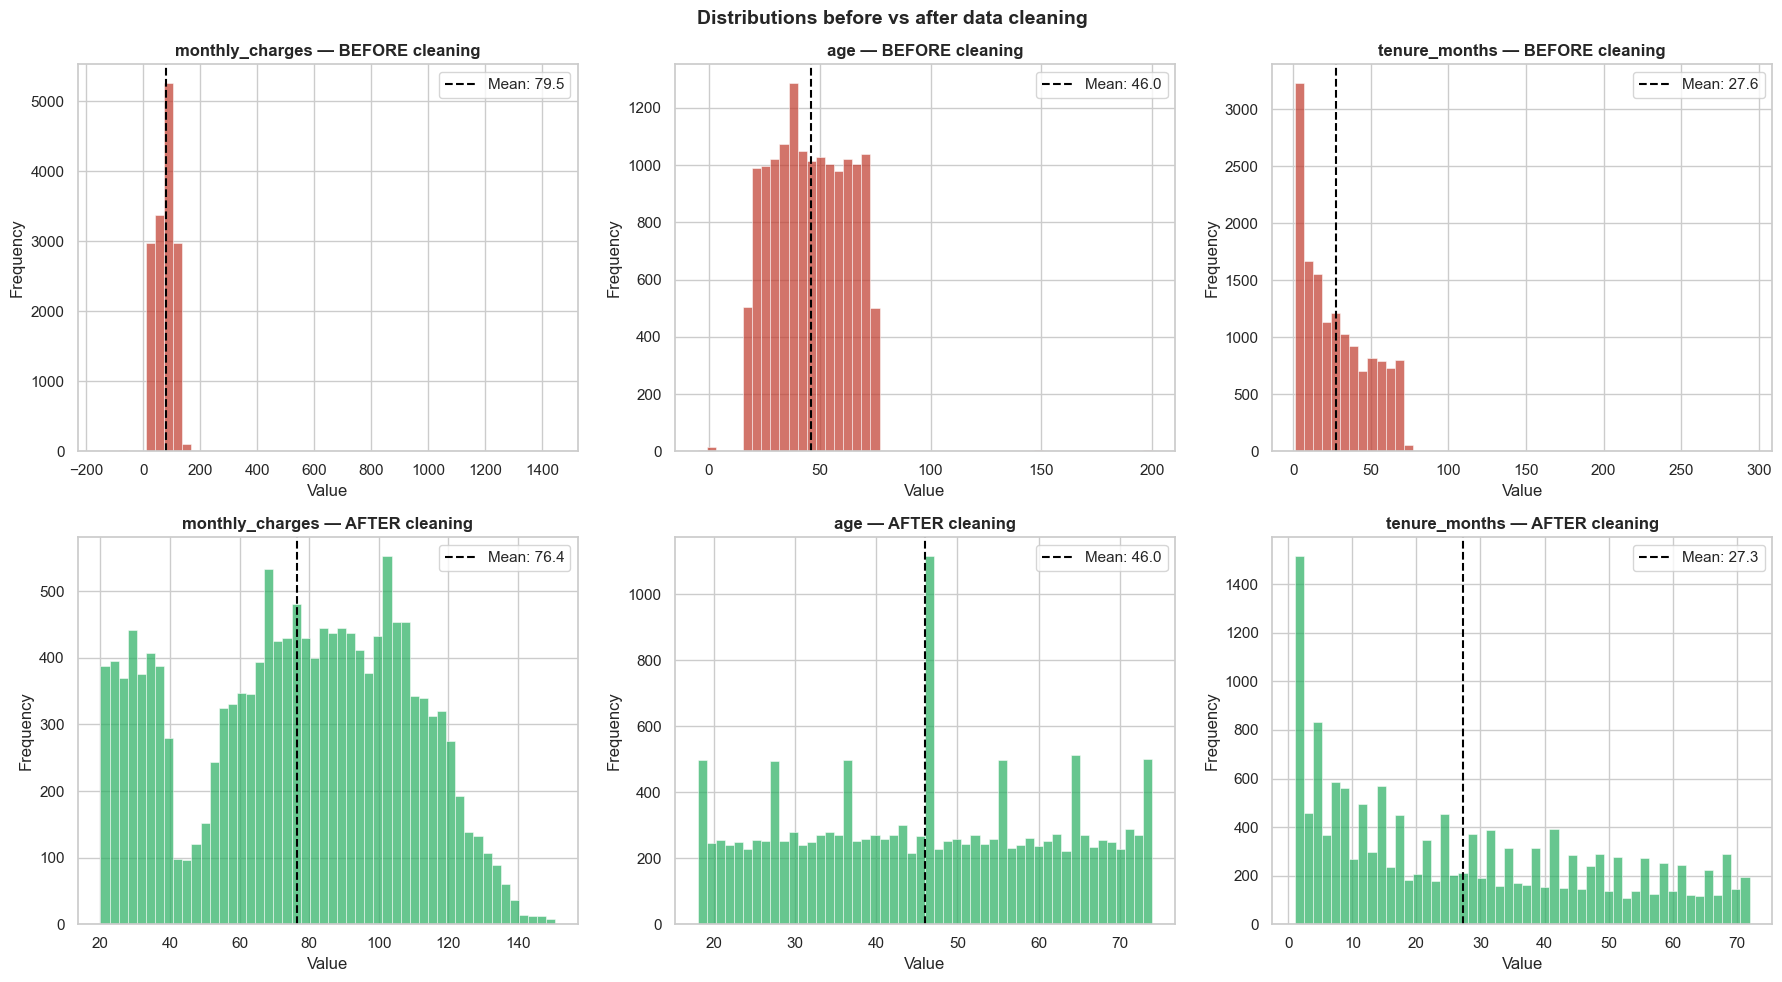

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cols_to_compare = [
    'monthly_charges', 'age', 'tenure_months'
]

for i, col in enumerate(cols_to_compare):
    data_before = df_original[col].dropna()
    data_after  = df[col]

    # Top row: before
    axes[0, i].hist(data_before, bins=50,
                    color='#c0392b', alpha=0.7,
                    edgecolor='white', linewidth=0.5)
    axes[0, i].set_title(f'{col} — BEFORE cleaning',
                          fontweight='bold')
    axes[0, i].set_xlabel('Value')
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].axvline(data_before.mean(),
                        color='black', linestyle='--',
                        label=f'Mean: {data_before.mean():.1f}')
    axes[0, i].legend()

    # Bottom row: after
    axes[1, i].hist(data_after, bins=50,
                    color='#27ae60', alpha=0.7,
                    edgecolor='white', linewidth=0.5)
    axes[1, i].set_title(f'{col} — AFTER cleaning',
                          fontweight='bold')
    axes[1, i].set_xlabel('Value')
    axes[1, i].set_ylabel('Frequency')
    axes[1, i].axvline(data_after.mean(),
                        color='black', linestyle='--',
                        label=f'Mean: {data_after.mean():.1f}')
    axes[1, i].legend()

plt.suptitle('Distributions before vs after data cleaning',
             fontsize=14, fontweight='bold')

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / '12_before_after_cleaning.png',
    bbox_inches='tight'
)

plt.show()

In [11]:
quality_report(df, "AFTER CLEANING")

print("\n── Final validation ──")

# Test 1: no missing values
assert df.isnull().sum().sum() == 0
print("✓ No missing values")

# Test 2: monthly_charges within valid range
assert df['monthly_charges'].between(0, 200).all()
print("✓ monthly_charges within [0, 200]")

# Test 3: age within valid range
assert df['age'].between(18, 100).all()
print("✓ age within [18, 100]")

# Test 4: tenure within valid range
assert df['tenure_months'].between(0, 72).all()
print("✓ tenure_months within [0, 72]")

# Test 5: gender only Male/Female
assert set(df['gender'].unique()).issubset({'Male', 'Female'})
print("✓ gender — only Male/Female")

# Test 6: contract — only 3 standard values
assert set(df['contract'].unique()).issubset(
    {'Month-to-month', 'One year', 'Two year'}
)
print("✓ contract — standardized values")

# Test 7: churn rate preserved
churn_rate_after = df['churn'].mean()
churn_rate_before = df_original['churn'].mean()
drift = abs(churn_rate_after - churn_rate_before)

assert drift < 0.03, f"Churn rate drifted by {drift:.1%}"

print(
    f"✓ Churn rate preserved "
    f"({churn_rate_before:.1%} → {churn_rate_after:.1%})"
)

# Test 8: logical inconsistency fixed
assert (
    (df['internet_service'] == 'No') &
    (df['online_security'] == 'Yes')
).sum() == 0

print("✓ Internet/security inconsistency resolved")

print(f"\n{'═'*45}")
print("  DATASET READY FOR FEATURE ENGINEERING")
print(f"  Final shape : {df.shape}")
print(f"{'═'*45}")


═══════════════════════════════════════════════════════
  DATA QUALITY REPORT — AFTER CLEANING
═══════════════════════════════════════════════════════
  Shape              : (15025, 18)
  Exact duplicates   : 0
  Total null values  : 0

  Numerical outliers :
    monthly_charges            0 IQR outliers
    age                        0 IQR outliers
    tenure_months              0 IQR outliers

── Final validation ──
✓ No missing values
✓ monthly_charges within [0, 200]
✓ age within [18, 100]
✓ tenure_months within [0, 72]
✓ gender — only Male/Female
✓ contract — standardized values
✓ Churn rate preserved (47.6% → 47.4%)
✓ Internet/security inconsistency resolved

═════════════════════════════════════════════
  DATASET READY FOR FEATURE ENGINEERING
  Final shape : (15025, 18)
═════════════════════════════════════════════


In [12]:
# Remove customer_id before saving
# It should never be used as a model feature
df_model = df.drop(columns=['customer_id'])

# Parquet — recommended format (preserves data types)
df_model.to_parquet(
    DATA_PROCESSED / 'telecom_churn_cleaned.parquet',
    index=False
)

# CSV — for quick visual inspection
df_model.to_csv(
    DATA_PROCESSED / 'telecom_churn_cleaned.csv',
    index=False
)

print("Files saved in data/processed/:")
print("  telecom_churn_cleaned.parquet")
print("  telecom_churn_cleaned.csv")

print(f"\nFinal shape   : {df_model.shape}")
print(f"Churn rate    : {df_model['churn'].mean():.1%}")
print(f"Null values   : {df_model.isnull().sum().sum()}")

# Verify file integrity
df_check = pd.read_parquet(
    DATA_PROCESSED / 'telecom_churn_cleaned.parquet'
)

assert df_check.shape == df_model.shape
print("\n✓ Parquet file successfully verified and readable")

Files saved in data/processed/:
  telecom_churn_cleaned.parquet
  telecom_churn_cleaned.csv

Final shape   : (15025, 17)
Churn rate    : 47.4%
Null values   : 0

✓ Parquet file successfully verified and readable
